# *ESTUDIO DE LAS ESTADÍSTICAS DE YOUTUBE 2025*

El trabajo consiste en estudiar las estadísticas de los canales de youtube
relacionados con la tecnología. Hacer un estudio descriptivo de los datos, viendo que canales tienen mayor interacción y por qué.

In [1]:
!pip install SciPY
!pip install PlotLy
!pip install pygwalker
!pip install seaborn
!pip install ydata_profiling
import pandas as pd
import pygwalker as pyg
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00


In [2]:
import pygwalker as pyg

## BLOQUE 1: Obtención y limpieza de datos

Los datos para el estudio de se obtienen de kaggle:

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mihikaajayjadhav/youtube-tech-channels-statistics-2025")

print("Path to dataset files:", path)

100%|██████████| 123k/123k [00:00<00:00, 321kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mihikaajayjadhav/youtube-tech-channels-statistics-2025/versions/1


Una vez descargados se suben al drive y se trabajan desde aquí

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = "/content/drive/My Drive/Colab Notebooks/Comp_AV/archivos_CSV/"

In [6]:
import pandas as pd
df1 = pd.read_csv(path + "youtube_tech_channels_20251120_133753.csv")
df2 = pd.read_csv(path + "youtube_tech_videos_20251120_133004.csv")

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_id        130 non-null    object
 1   channel_name      130 non-null    object
 2   description       127 non-null    object
 3   subscribers       130 non-null    int64 
 4   total_views       130 non-null    int64 
 5   total_videos      130 non-null    int64 
 6   created_date      130 non-null    object
 7   country           116 non-null    object
 8   uploads_playlist  130 non-null    object
 9   scraped_at        130 non-null    object
dtypes: int64(3), object(7)
memory usage: 10.3+ KB


Los datos están repatidos en 2 csv. En df1 están los datos por canal, con una descripción de los canales y sus estadísticas generales.
EN el df2 está catalogado cada vídeo de forma independiente, con sus estadisticas de duración, visualizaciones, likes, momento de la publicación, etc.

In [8]:
df1.head()

,channel_id,channel_name,description,subscribers,total_views,total_videos,created_date,country,uploads_playlist,scraped_at
0,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,"Linus Tech Tips is a passionate team of ""profe...",16600000,9092244390,6989,2008-11-25T00:46:52Z,CA,UUXuqSBlHAE6Xw-yeJA0Tunw,2025-11-20T13:37:53.306286
1,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286
2,UChIZGfcnjHI0DG4nweWEduw,TechSource,Join the Discord Server:\nhttps://discord.gg/T...,4010000,870967915,1897,2010-01-24T22:34:11Z,US,UUhIZGfcnjHI0DG4nweWEduw,2025-11-20T13:37:53.306286
3,UC4SVo0Ue36XCfOyb5Lh1viQ,Bro Code,Coding bootcamps HATE HIM! 🗿\n,2990000,178609297,1000,2019-10-10T14:40:46.568078Z,US,UU4SVo0Ue36XCfOyb5Lh1viQ,2025-11-20T13:37:53.306286
4,UCVeW9qkBjo3zosnqUbG7CFw,John Hammond,Free Cybersecurity Education and Ethical Hacking.,2080000,82120292,1740,2011-02-06T03:59:46Z,US,UUVeW9qkBjo3zosnqUbG7CFw,2025-11-20T13:37:53.306286


In [9]:
df2.head()

,video_id,title,published_at,views,likes,comments,duration,thumbnail,video_url,channel_id,channel_name,scraped_at,duration_readable
0,zzlS5dtzKKA,Most Important LTTStore Step,2025-11-18T22:47:05Z,211782,4012,88,PT27S,https://i.ytimg.com/vi/zzlS5dtzKKA/hqdefault.jpg,https://www.youtube.com/watch?v=zzlS5dtzKKA,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,0:27
1,Cmnfwabz0bA,This TV Factory is the Coolest I’ve Ever Seen,2025-11-18T19:20:33Z,572162,29769,1876,PT13M43S,https://i.ytimg.com/vi/Cmnfwabz0bA/hqdefault.jpg,https://www.youtube.com/watch?v=Cmnfwabz0bA,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,13:43
2,dnKy4UEdiyo,The Hardest Secrets I’ve Ever Kept - WAN Show ...,2025-11-15T06:24:56Z,523009,10052,1798,PT4H30M52S,https://i.ytimg.com/vi/dnKy4UEdiyo/hqdefault.jpg,https://www.youtube.com/watch?v=dnKy4UEdiyo,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,4:30:52
3,WP3LKBHL8vQ,Correct Way to Apply Thermal Paste,2025-11-14T18:27:41Z,3002514,63873,514,PT34S,https://i.ytimg.com/vi/WP3LKBHL8vQ/hqdefault.jpg,https://www.youtube.com/watch?v=WP3LKBHL8vQ,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,0:34
4,g3FkuZNSGkw,Valve’s New Console and Controller - STEAM Mac...,2025-11-13T13:54:48Z,4399002,161897,11391,PT14M31S,https://i.ytimg.com/vi/g3FkuZNSGkw/hqdefault.jpg,https://www.youtube.com/watch?v=g3FkuZNSGkw,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,14:31


In [10]:
# Hacemos copias de los dataframes para trabajar con ellos
ch = df1.copy()
vd = df2.copy()

Al dataframe de videos le añadimos la información del pais del que provienen los vídeos, dato que extraemos del datafrmae de canales

In [11]:
import pandas as pd
vd = pd.merge(vd, ch[['channel_id', 'country']], on='channel_id', how='left')
vd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           1300 non-null   object
 1   title              1300 non-null   object
 2   published_at       1300 non-null   object
 3   views              1300 non-null   int64 
 4   likes              1300 non-null   int64 
 5   comments           1300 non-null   int64 
 6   duration           1300 non-null   object
 7   thumbnail          1300 non-null   object
 8   video_url          1300 non-null   object
 9   channel_id         1300 non-null   object
 10  channel_name       1300 non-null   object
 11  scraped_at         1300 non-null   object
 12  duration_readable  1300 non-null   object
 13  country            1160 non-null   object
dtypes: int64(3), object(11)
memory usage: 142.3+ KB


Convertimos la duración de los vídeos en segundos, para poder trabajar con ello como int:

In [12]:
import re

def parse_duration(duration_str):
    if not isinstance(duration_str, str):
        return None

    # Regular expression to parse ISO 8601 duration format
    # Examples: PT27S, PT13M43S, PT4H30M52S
    match = re.match(r'PT(?:(?P<hours>\d+)H)?(?:(?P<minutes>\d+)M)?(?:(?P<seconds>\d+)S)?', duration_str)
    if not match:
        return None

    parts = match.groupdict()
    hours = int(parts.get('hours', 0) or 0)
    minutes = int(parts.get('minutes', 0) or 0)
    seconds = int(parts.get('seconds', 0) or 0)
    return hours * 3600 + minutes * 60 + seconds

vd['duration_seconds'] = vd['duration'].apply(parse_duration)
vd = vd.drop(columns=['duration'])
vd.info()
vd.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   video_id           1300 non-null   object 
 1   title              1300 non-null   object 
 2   published_at       1300 non-null   object 
 3   views              1300 non-null   int64  
 4   likes              1300 non-null   int64  
 5   comments           1300 non-null   int64  
 6   thumbnail          1300 non-null   object 
 7   video_url          1300 non-null   object 
 8   channel_id         1300 non-null   object 
 9   channel_name       1300 non-null   object 
 10  scraped_at         1300 non-null   object 
 11  duration_readable  1300 non-null   object 
 12  country            1160 non-null   object 
 13  duration_seconds   1294 non-null   float64
dtypes: float64(1), int64(3), object(10)
memory usage: 142.3+ KB


,video_id,title,published_at,views,likes,comments,thumbnail,video_url,channel_id,channel_name,scraped_at,duration_readable,country,duration_seconds
0,zzlS5dtzKKA,Most Important LTTStore Step,2025-11-18T22:47:05Z,211782,4012,88,https://i.ytimg.com/vi/zzlS5dtzKKA/hqdefault.jpg,https://www.youtube.com/watch?v=zzlS5dtzKKA,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,0:27,CA,27.0
1,Cmnfwabz0bA,This TV Factory is the Coolest I’ve Ever Seen,2025-11-18T19:20:33Z,572162,29769,1876,https://i.ytimg.com/vi/Cmnfwabz0bA/hqdefault.jpg,https://www.youtube.com/watch?v=Cmnfwabz0bA,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,13:43,CA,823.0
2,dnKy4UEdiyo,The Hardest Secrets I’ve Ever Kept - WAN Show ...,2025-11-15T06:24:56Z,523009,10052,1798,https://i.ytimg.com/vi/dnKy4UEdiyo/hqdefault.jpg,https://www.youtube.com/watch?v=dnKy4UEdiyo,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,4:30:52,CA,16252.0
3,WP3LKBHL8vQ,Correct Way to Apply Thermal Paste,2025-11-14T18:27:41Z,3002514,63873,514,https://i.ytimg.com/vi/WP3LKBHL8vQ/hqdefault.jpg,https://www.youtube.com/watch?v=WP3LKBHL8vQ,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,0:34,CA,34.0
4,g3FkuZNSGkw,Valve’s New Console and Controller - STEAM Mac...,2025-11-13T13:54:48Z,4399002,161897,11391,https://i.ytimg.com/vi/g3FkuZNSGkw/hqdefault.jpg,https://www.youtube.com/watch?v=g3FkuZNSGkw,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,2025-11-20T13:37:53.306773,14:31,CA,871.0


In [13]:
vd['duration_seconds'] = vd['duration_seconds'].fillna(0).astype(int)
vd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           1300 non-null   object
 1   title              1300 non-null   object
 2   published_at       1300 non-null   object
 3   views              1300 non-null   int64 
 4   likes              1300 non-null   int64 
 5   comments           1300 non-null   int64 
 6   thumbnail          1300 non-null   object
 7   video_url          1300 non-null   object
 8   channel_id         1300 non-null   object
 9   channel_name       1300 non-null   object
 10  scraped_at         1300 non-null   object
 11  duration_readable  1300 non-null   object
 12  country            1160 non-null   object
 13  duration_seconds   1300 non-null   int64 
dtypes: int64(4), object(10)
memory usage: 142.3+ KB


De forma análoga, extraemos del dataframe de canales el dato del mometnod e la creación del vídeo, y lo convertimos a int

In [14]:
ch['created_year'] = pd.to_datetime(ch['created_date'], format='ISO8601').dt.year
ch.head()

,channel_id,channel_name,description,subscribers,total_views,total_videos,created_date,country,uploads_playlist,scraped_at,created_year
0,UCXuqSBlHAE6Xw-yeJA0Tunw,Linus Tech Tips,"Linus Tech Tips is a passionate team of ""profe...",16600000,9092244390,6989,2008-11-25T00:46:52Z,CA,UUXuqSBlHAE6Xw-yeJA0Tunw,2025-11-20T13:37:53.306286,2008
1,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286,2014
2,UChIZGfcnjHI0DG4nweWEduw,TechSource,Join the Discord Server:\nhttps://discord.gg/T...,4010000,870967915,1897,2010-01-24T22:34:11Z,US,UUhIZGfcnjHI0DG4nweWEduw,2025-11-20T13:37:53.306286,2010
3,UC4SVo0Ue36XCfOyb5Lh1viQ,Bro Code,Coding bootcamps HATE HIM! 🗿\n,2990000,178609297,1000,2019-10-10T14:40:46.568078Z,US,UU4SVo0Ue36XCfOyb5Lh1viQ,2025-11-20T13:37:53.306286,2019
4,UCVeW9qkBjo3zosnqUbG7CFw,John Hammond,Free Cybersecurity Education and Ethical Hacking.,2080000,82120292,1740,2011-02-06T03:59:46Z,US,UUVeW9qkBjo3zosnqUbG7CFw,2025-11-20T13:37:53.306286,2011


In [15]:
ch['created_year'] = ch['created_year'].astype(np.int64)
ch.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_id        130 non-null    object
 1   channel_name      130 non-null    object
 2   description       127 non-null    object
 3   subscribers       130 non-null    int64 
 4   total_views       130 non-null    int64 
 5   total_videos      130 non-null    int64 
 6   created_date      130 non-null    object
 7   country           116 non-null    object
 8   uploads_playlist  130 non-null    object
 9   scraped_at        130 non-null    object
 10  created_year      130 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 11.3+ KB


In [16]:
ch.info()
vd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_id        130 non-null    object
 1   channel_name      130 non-null    object
 2   description       127 non-null    object
 3   subscribers       130 non-null    int64 
 4   total_views       130 non-null    int64 
 5   total_videos      130 non-null    int64 
 6   created_date      130 non-null    object
 7   country           116 non-null    object
 8   uploads_playlist  130 non-null    object
 9   scraped_at        130 non-null    object
 10  created_year      130 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 11.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           1300 non-null   objec

## Bloque 2: Análisis descriptivo

### APARTADO 1 : videos

Usando Profile report, hacemos una vista general de los datos para buscar correlaciones, desplazamientos o columnas vacias dentro del dataset. Así podemos acotar la busqueda y saber donde limpiar los datos.

In [17]:
from ydata_profiling import ProfileReport
report = ProfileReport(df1)
report.to_file("report.html")
report

Output hidden; open in https://colab.research.google.com to view.

In [18]:
from ydata_profiling import ProfileReport
report = ProfileReport(df2)
report.to_file("report.html")
report

Output hidden; open in https://colab.research.google.com to view.

Hacemos análisis univariante para ver donde tenemos que recortar o limpiar los datos

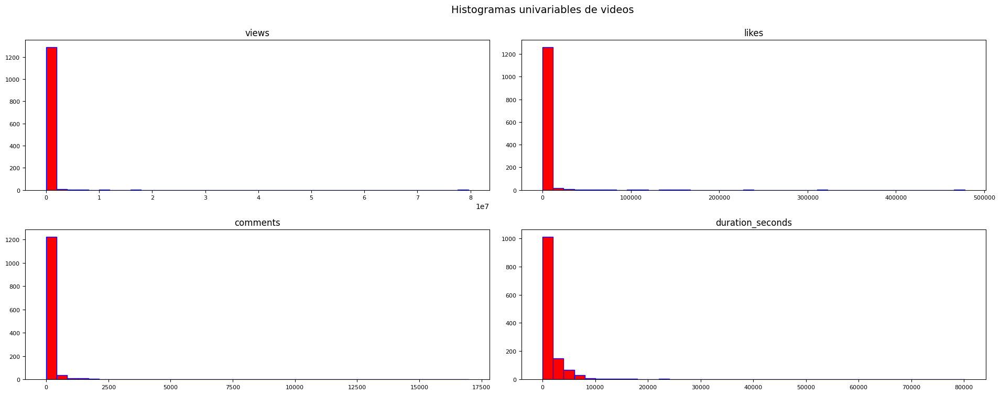

In [19]:
features_list = ['views', 'likes', 'comments','duration_seconds']
vd[features_list].hist(bins=40, edgecolor='b', linewidth=1.0,
                          xlabelsize=8, ylabelsize=8, grid=False,
                          figsize=(16,6), color='red')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('Histogramas univariables de videos', x=0.65, y=1.25, fontsize=14);

Viendo que los datos están muy desviados a la izquierda,vamos a sacar la media y la mediana de los valores para ver donde reducir:

In [20]:
median_value_views = vd['views'].median()
print(f"The median of 'views' is: {median_value_views}")
average_value_views = vd['views'].mean()
print(f"The average of 'views' is: {average_value_views}")

median_value_likes = vd['likes'].median()
print(f"The median of 'views' is: {median_value_likes}")
average_value_likes = vd['likes'].mean()
print(f"The average of 'views' is: {average_value_likes}")

median_value_comments = vd['comments'].median()
print(f"The median of 'comments' is: {median_value_comments}")
average_value_comments= vd['comments'].mean()
print(f"The average of 'comments' is: {average_value_comments}")

median_value_seconds = vd['duration_seconds'].median()
print(f"The median of 'duration_seconds' is: {median_value_seconds}")
average_value_seconds = vd['duration_seconds'].mean()
print(f"The average of 'duration_seconds' is: {average_value_seconds}")

The median of 'views' is: 3327.5
The average of 'views' is: 139482.40384615384
The median of 'views' is: 104.0
The average of 'views' is: 2868.8884615384613
The median of 'comments' is: 8.0
The average of 'comments' is: 133.8753846153846
The median of 'duration_seconds' is: 640.5
The average of 'duration_seconds' is: 1798.3161538461538


Viendo que sigue habiendo una distribución muy concentrada en el tramo cercano a la izquierda, y viendo que el límite establecido para las variables empieza a ser bajo para estándares de canales de youtube medianamente grandes, la 1ª conclusión que obtenemos es que la grán mayoría de los canales de youtube relacionados con la teconología son en realidad bastante pequeños, canales de nicho, centrados en temas concretos. Para comprobar la hipótesis, vamos a analizar las descripciones de los canales más grandes y la de los más pequeños para ver en qué están especializados cada uno.

Hipótesis antes de análisis: Los canales más grandes se especializan en noticias, novedades o grandes descubrimientos, los más pequeños en cambio se dedican a temas como reparaciones, consejos sobre distintos tipos de dispositivos, etc.

En esencia los canales más grandes son canales con un público y un nº de vistas fijo, es un canal que la gente revisa rutinariamente, mientras que el contenido de los canales más pequeños se centra en videos instructivos sobre como arreglar dispositivos, como formatearlos; son, ante todo, instrucciones que solo se ven dada una necesidad específica.

Vamos a filtrar los vídeos par quedarnos con la mitad de los videos cuyo valor de variable['likes','comments','

In [21]:
vd_fil = vd[vd['likes'] <= median_value_views]
vd_fil = vd[vd['comments'] <= median_value_comments]
vd_fil = vd[vd['views'] <= median_value_views]

vd_fil.info()

<class 'pandas.core.frame.DataFrame'>
Index: 650 entries, 32 to 1299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           650 non-null    object
 1   title              650 non-null    object
 2   published_at       650 non-null    object
 3   views              650 non-null    int64 
 4   likes              650 non-null    int64 
 5   comments           650 non-null    int64 
 6   thumbnail          650 non-null    object
 7   video_url          650 non-null    object
 8   channel_id         650 non-null    object
 9   channel_name       650 non-null    object
 10  scraped_at         650 non-null    object
 11  duration_readable  650 non-null    object
 12  country            564 non-null    object
 13  duration_seconds   650 non-null    int64 
dtypes: int64(4), object(10)
memory usage: 76.2+ KB


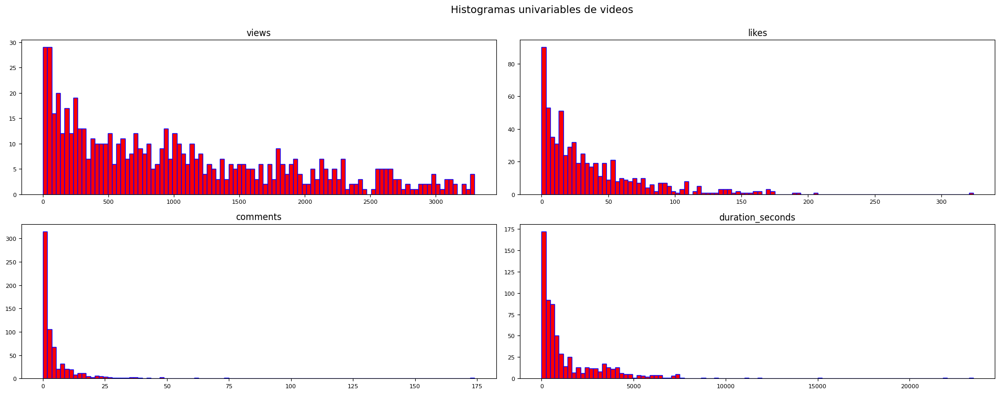

In [22]:
features_list = ['views', 'likes', 'comments','duration_seconds']
vd_fil[features_list].hist(bins=100, edgecolor='b', linewidth=1.0,
                          xlabelsize=8, ylabelsize=8, grid=False,
                          figsize=(16,6), color='red')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('Histogramas univariables de videos', x=0.65, y=1.25, fontsize=14);

Hacemos un mapa de correlaciones:

<Axes: >

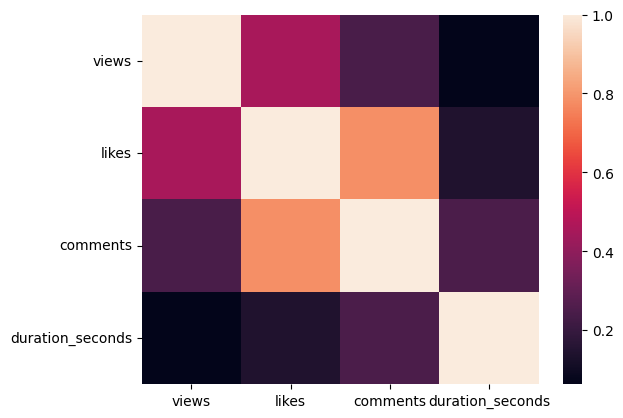

In [23]:
sns.heatmap(vd.select_dtypes([np.int64]).corr())

Curiosamente, la duración del video no parece afectar en nada en los comentarios, likes o visualizaciones. Parece que la clave de un video exitoso no es la duración del video, por lo tanto, no vamos limpiar los datos de duracion como hemos limpiado los demás

Hacemos un boxplot para ver mejor la distribución de las variables numéricas:

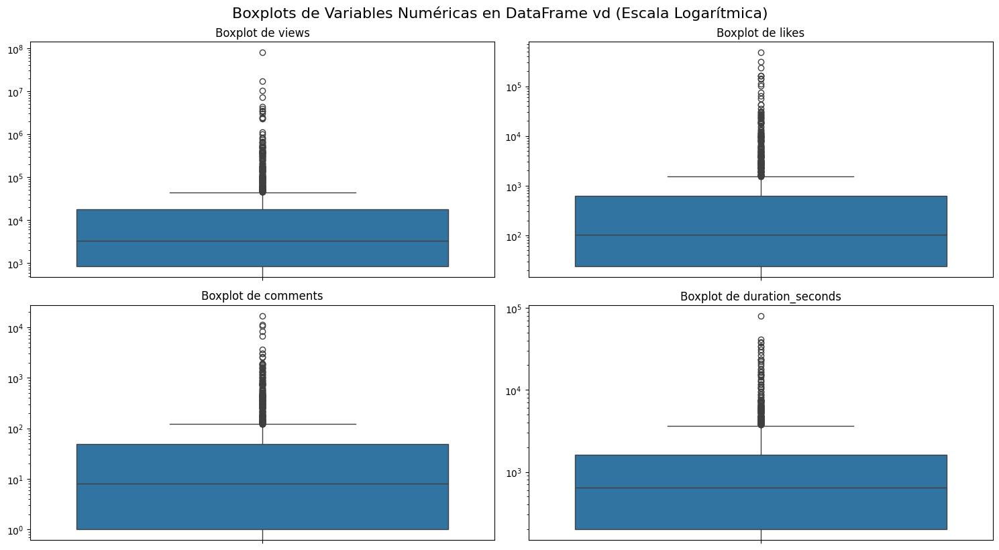

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns in vd DataFrame
vd_numerical_features = vd.select_dtypes(include=[np.number]).columns.tolist()

# Create boxplots for each numerical feature
plt.figure(figsize=(15, 8))
for i, feature in enumerate(vd_numerical_features):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=vd[feature])
    plt.yscale('log') # Set y-axis to logarithmic scale
    plt.title(f'Boxplot de {feature}')
    plt.ylabel('') # Remove y-label as it's redundant with title
plt.tight_layout()
plt.suptitle('Boxplots de Variables Numéricas en DataFrame vd (Escala Logarítmica)', y=1.02, fontsize=16)
plt.show()

Con los boxplotsa representamos los datos numéricos para ver sus cuartiles. La mitad de los vídeos tienen alrederor de 100 comentarios, entre 1000 y 10000 visitas, con unos 1000 likes y de una duración de aprox. 1000 segundos (alrededor de un cuarto de hora). De lo que se deduce que por cada 10 visitas sólo una comenta sobre el vídeo, por lo que la interacciones entre el  creador de vídeos y los suscriptores de los vídeos son escasasen comparación con su público total.

Para hacer el análisis más rápido, vamos a usar pygwalker. Primero ejecutamos pygwalker en una ventana, realizamos todas las gráficas pertinentes en la ventana.Después,copiando el código en la pestaña 'export_code', lo pegamos en una celda nueva, para que al ejecutarse la celda aparecza la gráfica.
Como las gráficas son  interactivas, pasar el cursor por encima de cualquier dato de las gráficas nos dice que datos contiene de los codificados dentro de la tabla:

In [25]:
pyg.walk(vd_fil)

Box(children=(HTML(value='\n<div id="ifr-pyg-000648454bff6c01igxanv8dKJ3QTW7k" style="height: auto">\n    <hea…

en esta gráfica hacemos una comparativa de visitas respecto a likes. En la gráfica hemos codificado el nº de segundos de duración en la opacidad de la tabla, y los paises en los colores:

In [26]:
vis_spec = r"""{"config":[{"config":{"defaultAggregated":false,"geoms":["auto"],"coordSystem":"generic","limit":-1,"timezoneDisplayOffset":0},"encodings":{"dimensions":[{"fid":"video_id","name":"video_id","basename":"video_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"title","name":"title","basename":"title","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"published_at","name":"published_at","basename":"published_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"thumbnail","name":"thumbnail","basename":"thumbnail","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"video_url","name":"video_url","basename":"video_url","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_id","name":"channel_id","basename":"channel_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_name","name":"channel_name","basename":"channel_name","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"scraped_at","name":"scraped_at","basename":"scraped_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"duration_readable","name":"duration_readable","basename":"duration_readable","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"gw_mea_key_fid","name":"Measure names","analyticType":"dimension","semanticType":"nominal"}],"measures":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"comments","name":"comments","basename":"comments","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"gw_count_fid","name":"Row count","analyticType":"measure","semanticType":"quantitative","aggName":"sum","computed":true,"expression":{"op":"one","params":[],"as":"gw_count_fid"}},{"fid":"gw_mea_val_fid","name":"Measure values","analyticType":"measure","semanticType":"quantitative","aggName":"sum"}],"rows":[{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"columns":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"color":[{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0}],"opacity":[{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"size":[],"shape":[],"radius":[],"theta":[],"longitude":[],"latitude":[],"geoId":[],"details":[],"filters":[],"text":[]},"layout":{"showActions":false,"showTableSummary":false,"stack":"stack","interactiveScale":false,"zeroScale":true,"size":{"mode":"full","width":320,"height":200},"format":{},"geoKey":"name","resolve":{"x":false,"y":false,"color":false,"opacity":false,"shape":false,"size":false},"renderer":"vega-lite"},"visId":"gw_ElMz","name":"Chart 1"},{"config":{"defaultAggregated":false,"geoms":["auto"],"coordSystem":"generic","limit":-1,"timezoneDisplayOffset":0},"encodings":{"dimensions":[{"fid":"video_id","name":"video_id","basename":"video_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"title","name":"title","basename":"title","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"published_at","name":"published_at","basename":"published_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"thumbnail","name":"thumbnail","basename":"thumbnail","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"video_url","name":"video_url","basename":"video_url","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_id","name":"channel_id","basename":"channel_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_name","name":"channel_name","basename":"channel_name","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"scraped_at","name":"scraped_at","basename":"scraped_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"duration_readable","name":"duration_readable","basename":"duration_readable","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"gw_mea_key_fid","name":"Measure names","analyticType":"dimension","semanticType":"nominal"}],"measures":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"comments","name":"comments","basename":"comments","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"gw_count_fid","name":"Row count","analyticType":"measure","semanticType":"quantitative","aggName":"sum","computed":true,"expression":{"op":"one","params":[],"as":"gw_count_fid"}},{"fid":"gw_mea_val_fid","name":"Measure values","analyticType":"measure","semanticType":"quantitative","aggName":"sum"}],"rows":[{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"columns":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"color":[{"fid":"comments","name":"comments","basename":"comments","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"opacity":[{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"size":[],"shape":[],"radius":[],"theta":[],"longitude":[],"latitude":[],"geoId":[],"details":[],"filters":[],"text":[]},"layout":{"showActions":false,"showTableSummary":false,"stack":"stack","interactiveScale":false,"zeroScale":true,"size":{"mode":"full","width":320,"height":200},"format":{},"geoKey":"name","resolve":{"x":false,"y":false,"color":false,"opacity":false,"shape":false,"size":false},"renderer":"vega-lite"},"visId":"gw_3_Zg","name":"Chart 2"}],"chart_map":{},"workflow_list":[{"workflow":[{"type":"view","query":[{"op":"raw","fields":["country","views","likes","duration_seconds"]}]}]},{"workflow":[{"type":"view","query":[{"op":"raw","fields":["views","likes","comments","duration_seconds"]}]}]}],"version":"0.5.0.0"}"""
pyg.walk(vd_fil, spec=vis_spec)

Output hidden; open in https://colab.research.google.com to view.

Se aprecia un clustering  en videos con pocas visitas y con pocos likes. En el apartado de paises, parece que estados unidos es el país con más videos sobre temas tecnológicos.

In [27]:
vis_spec = r"""{"config":[{"config":{"defaultAggregated":false,"geoms":["auto"],"coordSystem":"generic","limit":-1,"timezoneDisplayOffset":0},"encodings":{"dimensions":[{"fid":"video_id","name":"video_id","basename":"video_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"title","name":"title","basename":"title","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"published_at","name":"published_at","basename":"published_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"thumbnail","name":"thumbnail","basename":"thumbnail","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"video_url","name":"video_url","basename":"video_url","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_id","name":"channel_id","basename":"channel_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_name","name":"channel_name","basename":"channel_name","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"scraped_at","name":"scraped_at","basename":"scraped_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"duration_readable","name":"duration_readable","basename":"duration_readable","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"gw_mea_key_fid","name":"Measure names","analyticType":"dimension","semanticType":"nominal"}],"measures":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"comments","name":"comments","basename":"comments","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"gw_count_fid","name":"Row count","analyticType":"measure","semanticType":"quantitative","aggName":"sum","computed":true,"expression":{"op":"one","params":[],"as":"gw_count_fid"}},{"fid":"gw_mea_val_fid","name":"Measure values","analyticType":"measure","semanticType":"quantitative","aggName":"sum"}],"rows":[{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"columns":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"color":[{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0}],"opacity":[{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"size":[],"shape":[],"radius":[],"theta":[],"longitude":[],"latitude":[],"geoId":[],"details":[],"filters":[],"text":[]},"layout":{"showActions":false,"showTableSummary":false,"stack":"stack","interactiveScale":false,"zeroScale":true,"size":{"mode":"full","width":320,"height":200},"format":{},"geoKey":"name","resolve":{"x":false,"y":false,"color":false,"opacity":false,"shape":false,"size":false},"renderer":"vega-lite"},"visId":"gw_ElMz","name":"Chart 1"},{"config":{"defaultAggregated":false,"geoms":["auto"],"coordSystem":"generic","limit":-1,"timezoneDisplayOffset":0},"encodings":{"dimensions":[{"fid":"video_id","name":"video_id","basename":"video_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"title","name":"title","basename":"title","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"published_at","name":"published_at","basename":"published_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"thumbnail","name":"thumbnail","basename":"thumbnail","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"video_url","name":"video_url","basename":"video_url","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_id","name":"channel_id","basename":"channel_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_name","name":"channel_name","basename":"channel_name","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"scraped_at","name":"scraped_at","basename":"scraped_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"duration_readable","name":"duration_readable","basename":"duration_readable","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"gw_mea_key_fid","name":"Measure names","analyticType":"dimension","semanticType":"nominal"}],"measures":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"comments","name":"comments","basename":"comments","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"gw_count_fid","name":"Row count","analyticType":"measure","semanticType":"quantitative","aggName":"sum","computed":true,"expression":{"op":"one","params":[],"as":"gw_count_fid"}},{"fid":"gw_mea_val_fid","name":"Measure values","analyticType":"measure","semanticType":"quantitative","aggName":"sum"}],"rows":[{"fid":"likes","name":"likes","basename":"likes","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"columns":[{"fid":"views","name":"views","basename":"views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"color":[{"fid":"comments","name":"comments","basename":"comments","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"opacity":[{"fid":"duration_seconds","name":"duration_seconds","basename":"duration_seconds","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"size":[],"shape":[],"radius":[],"theta":[],"longitude":[],"latitude":[],"geoId":[],"details":[],"filters":[],"text":[]},"layout":{"showActions":false,"showTableSummary":false,"stack":"stack","interactiveScale":false,"zeroScale":true,"size":{"mode":"full","width":320,"height":200},"format":{},"geoKey":"name","resolve":{"x":false,"y":false,"color":false,"opacity":false,"shape":false,"size":false},"renderer":"vega-lite"},"visId":"gw_3_Zg","name":"Chart 2"}],"chart_map":{},"workflow_list":[{"workflow":[{"type":"view","query":[{"op":"raw","fields":["country","views","likes","duration_seconds"]}]}]},{"workflow":[{"type":"view","query":[{"op":"raw","fields":["views","likes","comments","duration_seconds"]}]}]}],"version":"0.5.0.0"}"""
pyg.walk(vd_fil, spec=vis_spec)

Output hidden; open in https://colab.research.google.com to view.

Realizamos una gráfica similar, pero esta vez codificamos en el color el nº de comentarios. Como hemos señalado antes, la mayoría de los videos no tienen una cantidad significativa de comentarios.

### Apartado 2: Canales

Como antes, primero hacemos un análisi univariante de las variables numéricas para ver como son los datos:

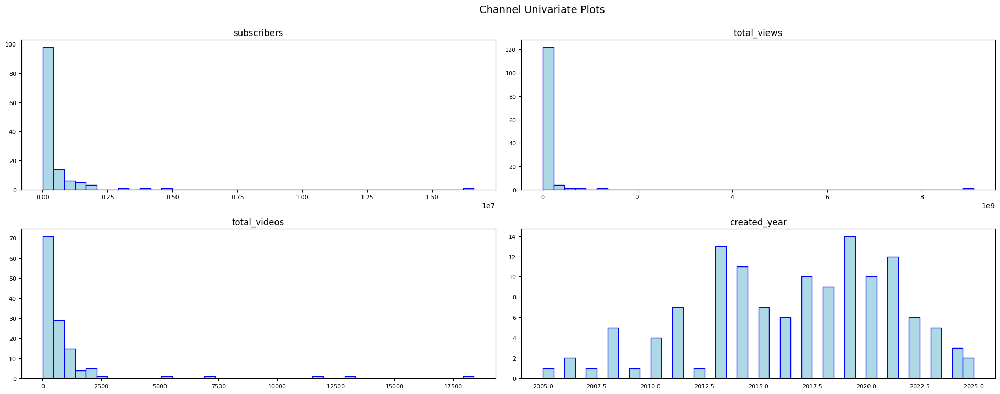

In [28]:
ch_numerical_features = ['subscribers', 'total_views', 'total_videos', 'created_year']
ch[ch_numerical_features].hist(bins=40, edgecolor='b', linewidth=1.0,
                          xlabelsize=8, ylabelsize=8, grid=False,
                          figsize=(16,6), color='lightblue')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('Channel Univariate Plots', x=0.65, y=1.25, fontsize=14);

Calculamos medias y medianas para ver si hay que modificar o limpiar algunos datos:

In [29]:
median_value_subscribers = ch['subscribers'].median()
print(f"The median of 'subscribers' is: {median_value_subscribers}")
average_value_subscribers = ch['subscribers'].mean()
print(f"The average of 'subscribers' is: {average_value_subscribers}")

median_value_total_views = ch['total_views'].median()
print(f"The median of 'total_views' is: {median_value_total_views}")
average_value_total_views = ch['total_views'].mean()
print(f"The average of 'total_views' is: {average_value_total_views}")


The median of 'subscribers' is: 120000.0
The average of 'subscribers' is: 512343.8461538461
The median of 'total_views' is: 10592617.5
The average of 'total_views' is: 123715522.78461538


Hacemos los boxplots asociados:

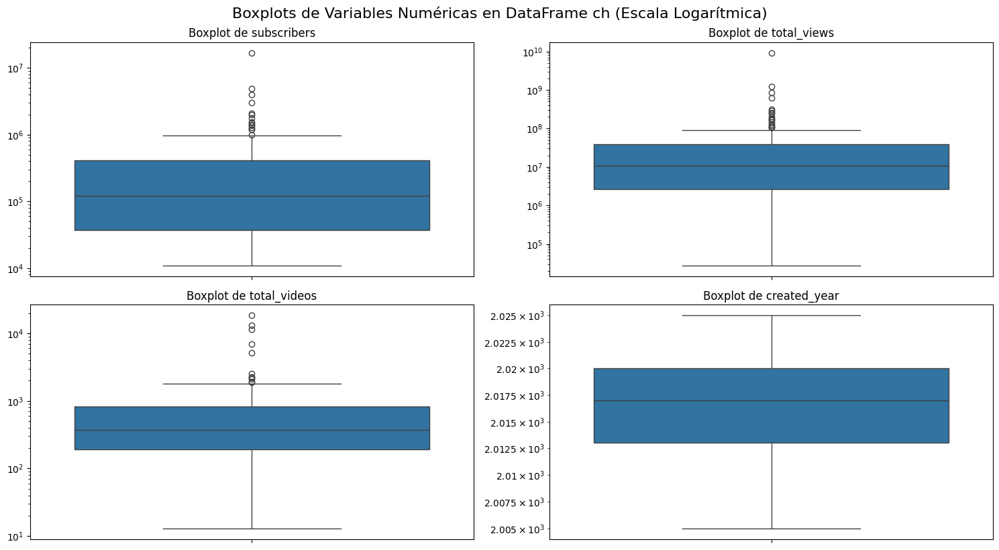

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns in vd DataFrame
ch_numerical_features = ch.select_dtypes(include=[np.number]).columns.tolist()

# Create boxplots for each numerical feature
plt.figure(figsize=(15, 8))
for i, feature in enumerate(ch_numerical_features):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=ch[feature])
    plt.yscale('log') # Set y-axis to logarithmic scale
    plt.title(f'Boxplot de {feature}')
    plt.ylabel('') # Remove y-label as it's redundant with title
plt.tight_layout()
plt.suptitle('Boxplots de Variables Numéricas en DataFrame ch (Escala Logarítmica)', y=1.02, fontsize=16)
plt.show()

Los canales en general tienen alrededor de 100.000 suscriptores, donde se acumulan un total de alrededor de 10 millones de visitas en total a lo largo de su existencia. el total de vídeos hechos son entre mil y diezmil. Para poder ver con más claridad el nº de canales creados, Hacemos un boxplot representando el nº de canales creados por año:

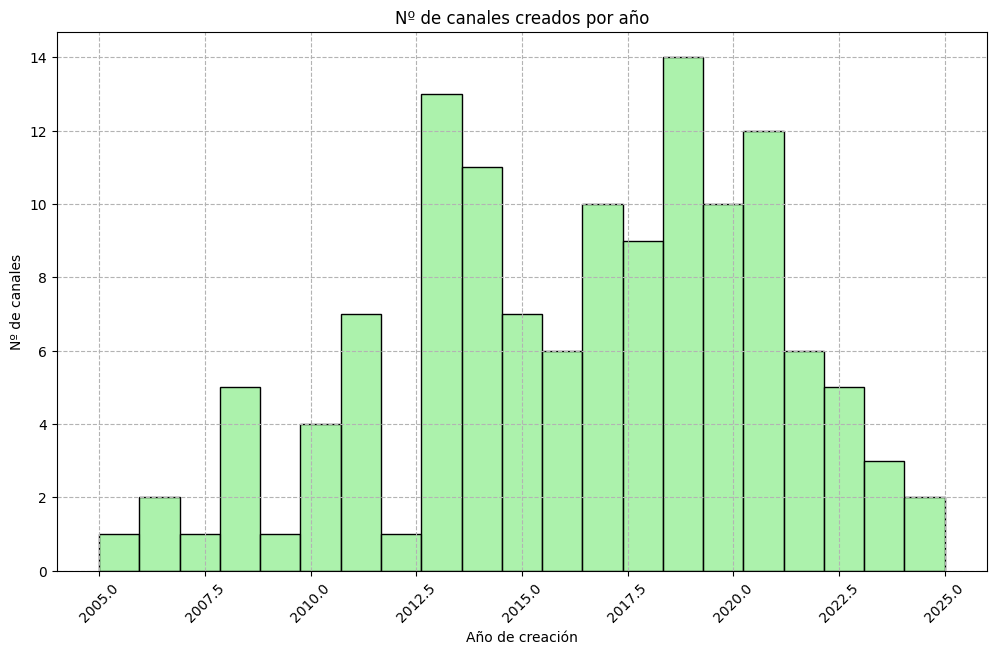

In [31]:
plt.figure(figsize=(12, 7))
sns.histplot(data=ch, x='created_year', bins=ch['created_year'].nunique(), kde=False, color='lightgreen')
plt.title('Nº de canales creados por año')
plt.xlabel('Año de creación')
plt.ylabel('Nº de canales')
plt.xticks(rotation=45)
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

Viendo la gráfica, se aprecia que el año con más creación de canales fue 2019, con una tendencia positiva hasta ese año y un descenso desde entonces.

para continuar con el análisis, hacemos un mapa de calor para ver correlación de variables:

<Axes: >

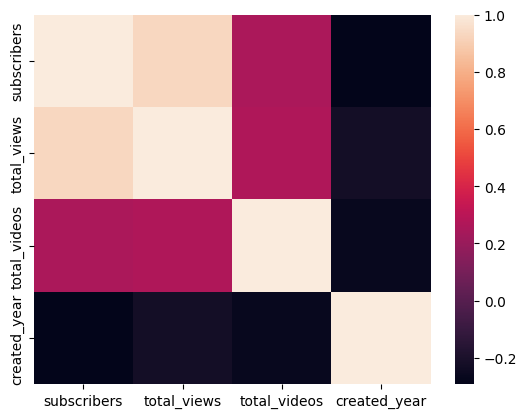

In [32]:
sns.heatmap(ch.select_dtypes([np.int64]).corr())

Curiosamente, el año de creación de los canales no parece influenciar para nada en las visitas o suscriptores, por lo que hay canales muy viejos con pocos suscriptores y canales muy nuevos con muchos.

In [33]:
pyg.walk(ch)

Box(children=(HTML(value='\n<div id="ifr-pyg-000648454c72b2e37LHy0WfR8gNvXnbu" style="height: auto">\n    <hea…

In [34]:
vis_spec = r"""{"config":[{"config":{"defaultAggregated":false,"geoms":["auto"],"coordSystem":"generic","limit":-1,"timezoneDisplayOffset":0},"encodings":{"dimensions":[{"fid":"channel_id","name":"channel_id","basename":"channel_id","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"channel_name","name":"channel_name","basename":"channel_name","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"description","name":"description","basename":"description","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"created_date","name":"created_date","basename":"created_date","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"uploads_playlist","name":"uploads_playlist","basename":"uploads_playlist","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"scraped_at","name":"scraped_at","basename":"scraped_at","semanticType":"nominal","analyticType":"dimension","offset":0},{"fid":"gw_mea_key_fid","name":"Measure names","analyticType":"dimension","semanticType":"nominal"}],"measures":[{"fid":"subscribers","name":"subscribers","basename":"subscribers","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"total_views","name":"total_views","basename":"total_views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"total_videos","name":"total_videos","basename":"total_videos","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"created_year","name":"created_year","basename":"created_year","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0},{"fid":"gw_count_fid","name":"Row count","analyticType":"measure","semanticType":"quantitative","aggName":"sum","computed":true,"expression":{"op":"one","params":[],"as":"gw_count_fid"}},{"fid":"gw_mea_val_fid","name":"Measure values","analyticType":"measure","semanticType":"quantitative","aggName":"sum"}],"rows":[{"fid":"total_views","name":"total_views","basename":"total_views","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"columns":[{"fid":"subscribers","name":"subscribers","basename":"subscribers","analyticType":"measure","semanticType":"quantitative","aggName":"sum","offset":0}],"color":[{"fid":"country","name":"country","basename":"country","semanticType":"nominal","analyticType":"dimension","offset":0}],"opacity":[],"size":[],"shape":[],"radius":[],"theta":[],"longitude":[],"latitude":[],"geoId":[],"details":[],"filters":[],"text":[]},"layout":{"showActions":false,"showTableSummary":false,"stack":"stack","interactiveScale":false,"zeroScale":true,"size":{"mode":"full","width":320,"height":200},"format":{},"geoKey":"name","resolve":{"x":false,"y":false,"color":false,"opacity":false,"shape":false,"size":false},"renderer":"vega-lite"},"visId":"gw_PQ9x","name":"Chart 1"}],"chart_map":{},"workflow_list":[{"workflow":[{"type":"view","query":[{"op":"raw","fields":["country","subscribers","total_views"]}]}]}],"version":"0.5.0.0"}"""
pyg.walk(ch, spec=vis_spec)

Box(children=(HTML(value='\n<div id="ifr-pyg-000648454c76b01e7nNr0If6uDvtWPaq" style="height: auto">\n    <hea…

El dato extremo que aparece en la derecha es un canal llamado linus tech tips, que es de lejos el canal más grande en cuanto a contenido de tecnología se refiere en youtube. para poder estudiar mejor el apartado de canales, vamsoa  suprimir sus valores del dataframe para poder estudiar las tendencias del resto de los datos:

In [35]:
ch_fil = ch[ch['channel_id'] != 'UCXuqSBlHAE6Xw-yeJA0Tunw']
display(ch_fil.head())
ch_fil.info()

,channel_id,channel_name,description,subscribers,total_views,total_videos,created_date,country,uploads_playlist,scraped_at,created_year
1,UCWv7vMbMWH4-V0ZXdmDpPBA,Programming with Mosh,"Hi! I'm Mosh 👋, a software engineer with over ...",4860000,257598451,243,2014-10-07T00:40:53Z,US,UUWv7vMbMWH4-V0ZXdmDpPBA,2025-11-20T13:37:53.306286,2014
2,UChIZGfcnjHI0DG4nweWEduw,TechSource,Join the Discord Server:\nhttps://discord.gg/T...,4010000,870967915,1897,2010-01-24T22:34:11Z,US,UUhIZGfcnjHI0DG4nweWEduw,2025-11-20T13:37:53.306286,2010
3,UC4SVo0Ue36XCfOyb5Lh1viQ,Bro Code,Coding bootcamps HATE HIM! 🗿\n,2990000,178609297,1000,2019-10-10T14:40:46.568078Z,US,UU4SVo0Ue36XCfOyb5Lh1viQ,2025-11-20T13:37:53.306286,2019
4,UCVeW9qkBjo3zosnqUbG7CFw,John Hammond,Free Cybersecurity Education and Ethical Hacking.,2080000,82120292,1740,2011-02-06T03:59:46Z,US,UUVeW9qkBjo3zosnqUbG7CFw,2025-11-20T13:37:53.306286,2011
5,UCeeFfhMcJa1kjtfZAGskOCA,TechLinked,"TechLinked keeps you up to date with a fast, f...",1990000,628661984,1214,2018-05-03T19:49:25Z,CA,UUeeFfhMcJa1kjtfZAGskOCA,2025-11-20T13:37:53.306286,2018


<class 'pandas.core.frame.DataFrame'>
Index: 129 entries, 1 to 129
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel_id        129 non-null    object
 1   channel_name      129 non-null    object
 2   description       126 non-null    object
 3   subscribers       129 non-null    int64 
 4   total_views       129 non-null    int64 
 5   total_videos      129 non-null    int64 
 6   created_date      129 non-null    object
 7   country           115 non-null    object
 8   uploads_playlist  129 non-null    object
 9   scraped_at        129 non-null    object
 10  created_year      129 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 12.1+ KB


dado que al hacer las gráficas en pygwalker los resultados no eran del todo los esperados, se ha obtado por hacer las gráficas en un estilo más clásico para poder resprerenstar mejor los datos:

A continuación,vamos ha hacer unos scatterplot para comparar variables 2 a 2:

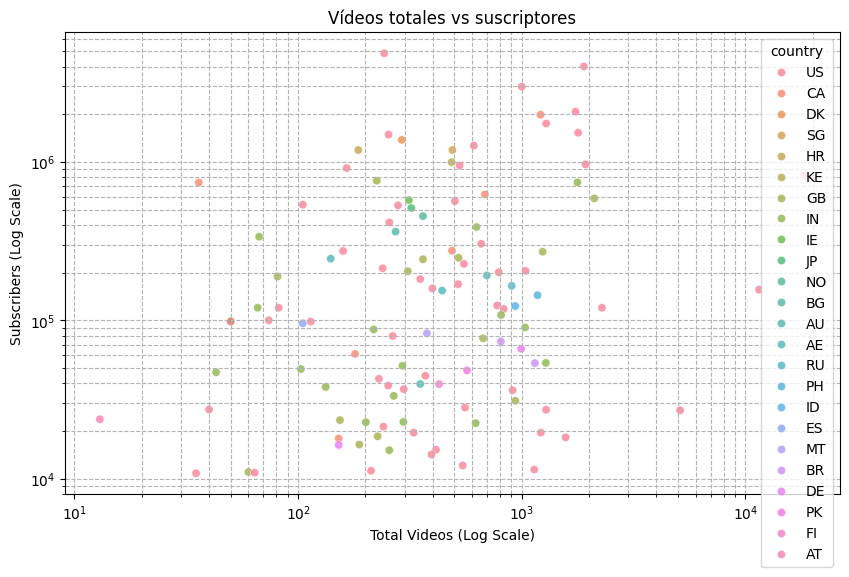

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_videos', y='subscribers', data=ch_fil, alpha=0.7, hue='country')
plt.xscale('log')
plt.yscale('log')
plt.title('Vídeos totales vs suscriptores')
plt.xlabel('Total Videos (Log Scale)')
plt.ylabel('Subscribers (Log Scale)')
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

tanto en el Nº de vídeos como en el número de suscriptores, los canales Estadounidenses son los dominates.

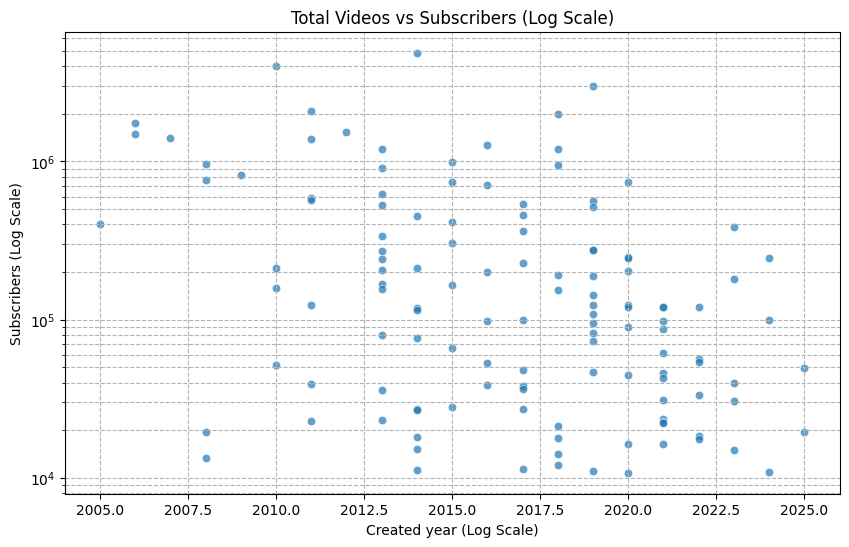

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='created_year', y='subscribers', data=ch_fil, alpha=0.7)
plt.title('Total Videos vs Subscribers (Log Scale)')
plt.yscale('log')
plt.xlabel('Created year (Log Scale)')
plt.ylabel('Subscribers (Log Scale)')
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

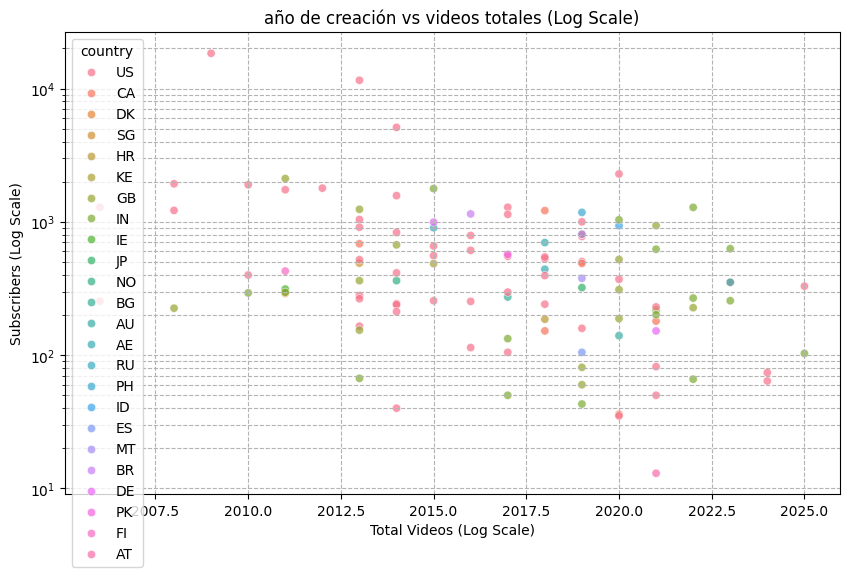

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='created_year', y='total_videos', data=ch_fil, alpha=0.7, hue='country')
plt.yscale('log')
plt.title('año de creación vs videos totales (Log Scale)')
plt.xlabel('Total Videos (Log Scale)')
plt.ylabel('Subscribers (Log Scale)')
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

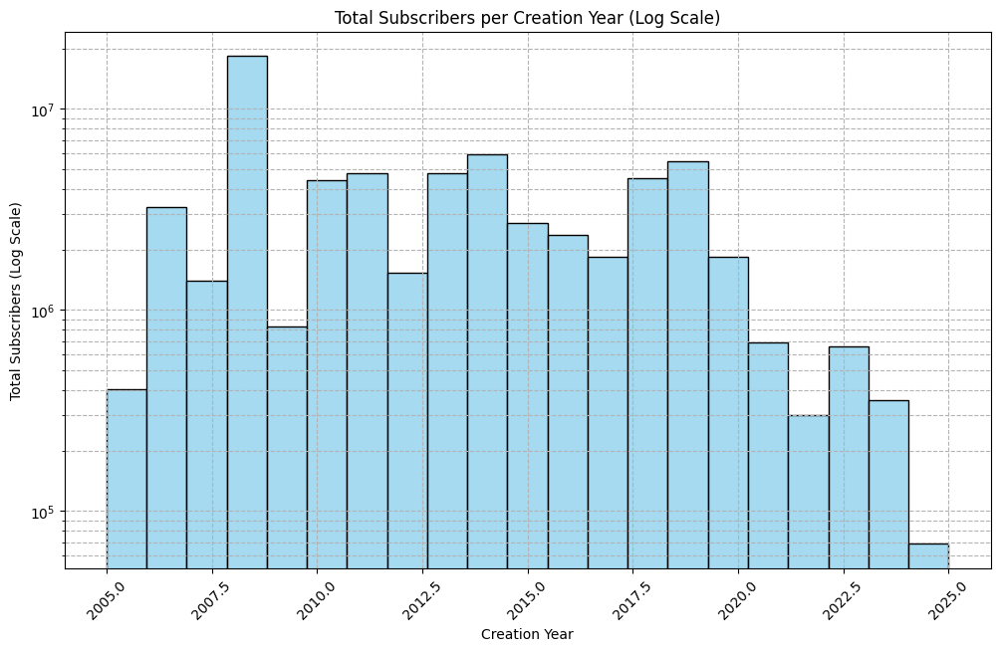

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 7))
# Plot a histogram of created_year, weighted by subscribers
# Using number of unique years as bins to avoid ValueError with weights
sns.histplot(data=ch, x='created_year', weights='subscribers',
             bins=ch['created_year'].nunique(),
             kde=False, color='skyblue')
plt.yscale('log')
plt.title('Total Subscribers per Creation Year (Log Scale)')
plt.xlabel('Creation Year')
plt.ylabel('Total Subscribers (Log Scale)')
plt.xticks(rotation=45)
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

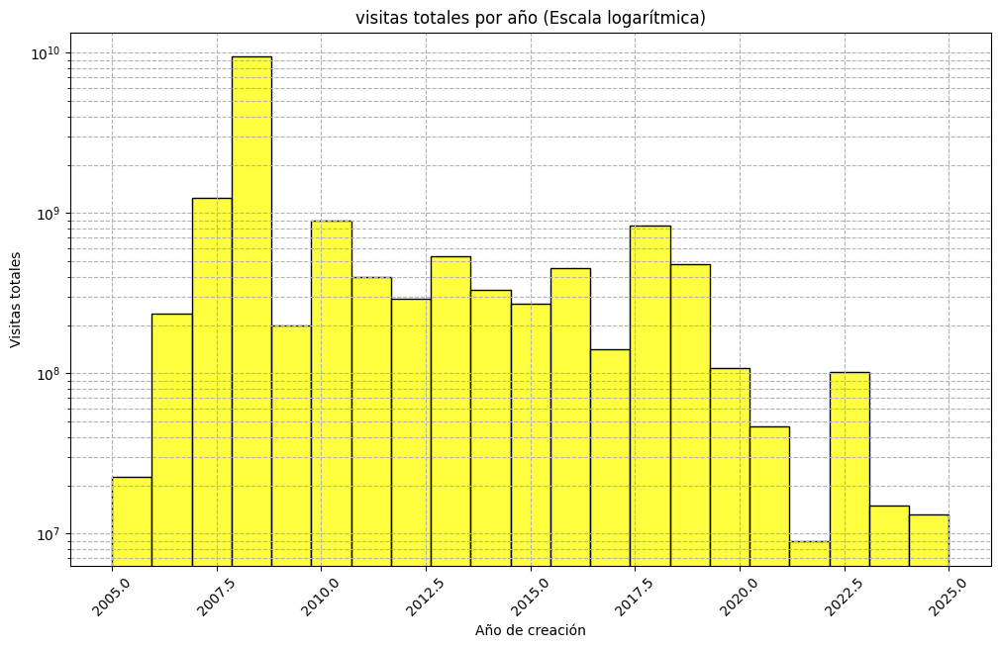

In [40]:
plt.figure(figsize=(12, 7))
# Plot a histogram of created_year, weighted by subscribers
# Using number of unique years as bins to avoid ValueError with weights
sns.histplot(data=ch, x='created_year', weights='total_views',
             bins=ch['created_year'].nunique(),
             kde=False, color='YELLOW')
plt.yscale('log')
plt.title('visitas totales por año (Escala logarítmica)')
plt.xlabel('Año de creación')
plt.ylabel('Visitas totales')
plt.xticks(rotation=45)
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

In [41]:
linus_tech_tips_year = ch[ch['channel_name'] == 'Linus Tech Tips']['created_year']
print(f"El año de creación del canal Linus Tech Tips es: {linus_tech_tips_year.iloc[0]}")

El año de creación del canal Linus Tech Tips es: 2008


En general se cumple a mayor antigüedad, mayor número de suscriptores, pero tambíen es verdad que canales más recientes tienen bastantes seguidores. Pero en lo relativo a visitas totales, los canales de 2007 dominan absolutamente. Una vez más, 'linus tech tips' domina absolutamente el mercado. Esto se aprecia mucho mejor si hacemso las gfráficas otra vez pero esta vez suprimiendoelcanal más grande:

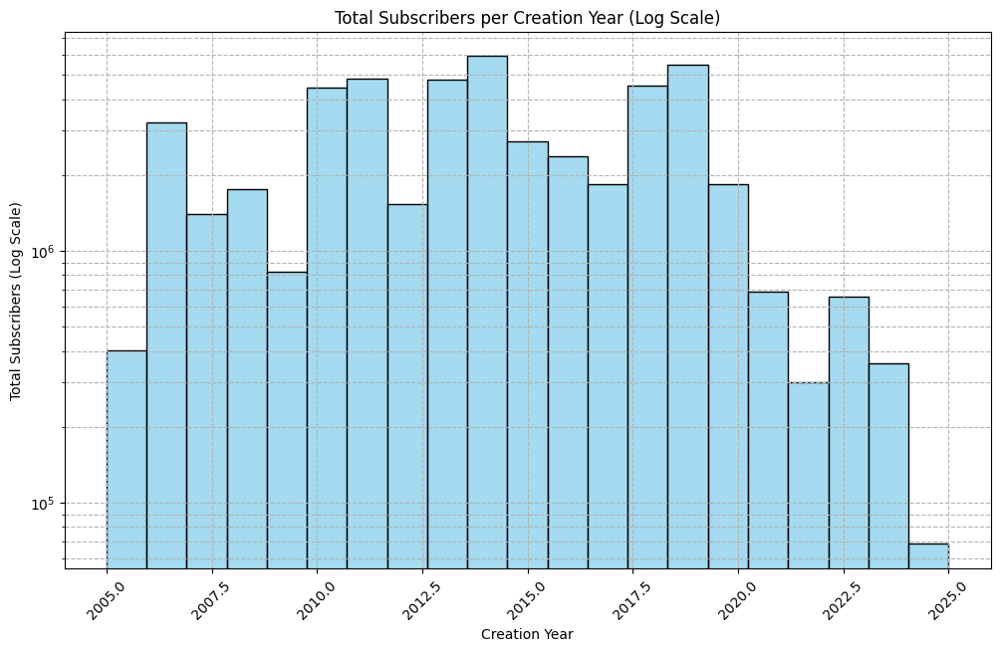

In [42]:
plt.figure(figsize=(12, 7))
# Plot a histogram of created_year, weighted by subscribers
# Using number of unique years as bins to avoid ValueError with weights
sns.histplot(data=ch_fil, x='created_year', weights='subscribers',
             bins=ch['created_year'].nunique(),
             kde=False, color='skyblue')
plt.yscale('log')
plt.title('Total Subscribers per Creation Year (Log Scale)')
plt.xlabel('Creation Year')
plt.ylabel('Total Subscribers (Log Scale)')
plt.xticks(rotation=45)
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

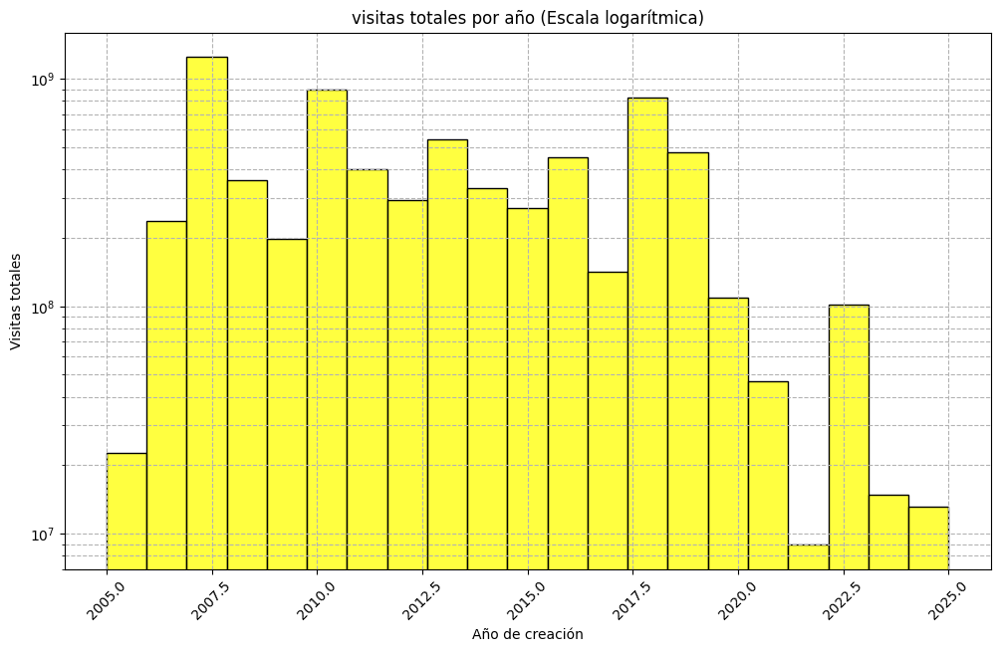

In [43]:
plt.figure(figsize=(12, 7))
# Plot a histogram of created_year, weighted by subscribers
# Using number of unique years as bins to avoid ValueError with weights
sns.histplot(data=ch_fil, x='created_year', weights='total_views',
             bins=ch['created_year'].nunique(),
             kde=False, color='YELLOW')
plt.yscale('log')
plt.title('visitas totales por año (Escala logarítmica)')
plt.xlabel('Año de creación')
plt.ylabel('Visitas totales')
plt.xticks(rotation=45)
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()

#Conclusiones

Las conclusioens viene a ser un compendio de de los análisis de los esultados obtrenidos a lo largo del estudio. Parece ser que los canales de yotube del sector tecnológico están dominados por cxanels estadounidesndes, en especial lius tech tips. El formato de video más popular es de alrededor de 15 minutos de duración, con entre mil y diezmil visitas, de las cuales sólo el centenar dejan comentarios.
Viendo la gráfica de creación de canales por año, se ve un aumento de creación de canales por año desde 2007, y la tendencia se mantuvo hasta 2019, justo antes de la pandémia. Esto coincide con el aumento del interés por la tecnología como motor social y económico del siglo XXI. Parece que después de la pandémia, el nicho de mercado de los canales tecnológicos quedó completo, y esee factor puede ser el qué más haya contribuido a que el surgimiento de nuevos canales sea menor desde 2020, alcanzando un mínimo en 2025.  
 Como apreciación final, vamos a ver como es la descripción del canal linus tech tips, información que se incluye en el propio dataset:

In [44]:
linus_tech_tips_description = ch[ch['channel_name'] == 'Linus Tech Tips']['description']
# Access the first element of the Series to get the full string
print(linus_tech_tips_description.iloc[0])

Linus Tech Tips is a passionate team of "professionally curious" experts in consumer technology and video production who aim to educate and entertain.

Sponsorship Inquiries: partnerships@linusmediagroup.com



# Task
To ensure data consistency and prepare for SQL schema generation, I'll verify the `channel_id` common to both the `ch` and `vd` DataFrames. Any `channel_id` values in `vd` that do not exist in `ch` will be removed to maintain referential integrity. I'll also confirm that the `channel_id` columns have compatible data types in both DataFrames. Finally, I will select the relevant columns from both `ch` and `vd` to create the `channels` and `videos` tables respectively, removing any unnecessary columns.

## Check Data Consistency and Prepare for SQL

### Subtask:
Verify the consistency of 'channel_id' between the 'ch' and 'vd' DataFrames, remove inconsistent entries, and select relevant columns for the final 'channels' and 'videos' tables.


**Reasoning**:
First, I will convert the 'channel_id' columns in both `ch` and `vd` DataFrames to string type to ensure consistency. Then, I will identify the unique channel IDs from the `ch` DataFrame and use them to filter the `vd` DataFrame, removing any videos associated with non-existent channels, to ensure data integrity.



In [45]:
ch['channel_id'] = ch['channel_id'].astype(str)
vd['channel_id'] = vd['channel_id'].astype(str)

valid_channel_ids = ch['channel_id'].unique()
vd = vd[vd['channel_id'].isin(valid_channel_ids)]

print("DataFrames 'ch' and 'vd' channel_ids checked and 'vd' filtered.")
vd.info()

DataFrames 'ch' and 'vd' channel_ids checked and 'vd' filtered.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           1300 non-null   object
 1   title              1300 non-null   object
 2   published_at       1300 non-null   object
 3   views              1300 non-null   int64 
 4   likes              1300 non-null   int64 
 5   comments           1300 non-null   int64 
 6   thumbnail          1300 non-null   object
 7   video_url          1300 non-null   object
 8   channel_id         1300 non-null   object
 9   channel_name       1300 non-null   object
 10  scraped_at         1300 non-null   object
 11  duration_readable  1300 non-null   object
 12  country            1160 non-null   object
 13  duration_seconds   1300 non-null   int64 
dtypes: int64(4), object(10)
memory usage: 142.3+ KB
